In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy import stats
import os

### Loading the data

In [2]:
df = pd.read_csv('../data/tanzania.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


## **Data Loading & Date Parsing**

### Add a Country column with the Ethiopia value

In [3]:
df_clean = df.copy()

In [4]:
df_clean["Country"] = "Tanzania"
df_clean.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


### Convert the YEAR and DOY columns into a proper datetime column

In [5]:
df_clean["Date"] = pd.to_datetime(df_clean["YEAR"] * 1000 + df_clean["DOY"], format="%Y%j")
df_clean.drop(columns=["DOY"], inplace=True)
df_clean.sample(5)


,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
1821,2019,28.09,29.69,26.74,2.95,12.24,85.62,3.94,4.75,100.23,20.42,Tanzania,2019-12-27
3264,2023,27.14,28.81,25.72,3.09,10.76,83.53,2.29,3.09,100.59,18.77,Tanzania,2023-12-09
1959,2020,26.38,27.95,25.02,2.93,1.43,86.05,2.61,4.06,100.88,18.44,Tanzania,2020-05-13
1286,2018,24.70,26.86,22.94,3.92,0.03,77.14,5.29,6.54,101.32,14.82,Tanzania,2018-07-10
1940,2020,26.64,28.45,25.27,3.18,0.67,85.11,3.30,4.48,100.63,18.55,Tanzania,2020-04-24


### Extract Month as a separate colum

In [6]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean.sample(5)

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
3118,2023,25.26,28.18,22.64,5.54,0.13,71.38,5.35,6.92,101.36,14.08,Tanzania,2023-07-16,7
1346,2018,26.04,29.16,23.55,5.61,1.10,71.27,3.63,4.77,101.02,14.79,Tanzania,2018-09-08,9
199,2015,25.55,28.01,24.09,3.92,0.34,76.57,4.85,6.10,101.21,15.46,Tanzania,2015-07-19,7
2158,2020,27.45,29.73,25.95,3.78,5.75,80.98,2.62,3.59,100.61,18.48,Tanzania,2020-11-28,11
2668,2022,27.46,29.16,26.01,3.15,25.62,79.66,1.13,2.44,100.40,18.20,Tanzania,2022-04-22,4


## **Summary Statistics & Missing-Value Report**

#### Replace all occurrences of -999 with np.nan

In [7]:
df_clean.replace(-999, np.nan, inplace=True)
df_clean.sample(5)

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
4045,2026,27.35,29.61,26.19,3.42,5.41,76.97,4.97,5.36,100.66,17.46,Tanzania,2026-01-28,1
2710,2022,25.58,28.03,23.65,4.38,0.47,67.28,6.40,8.06,101.09,13.56,Tanzania,2022-06-03,6
53,2015,28.55,30.90,26.76,4.14,3.31,73.60,3.25,3.82,100.59,17.86,Tanzania,2015-02-23,2
3128,2023,25.72,28.68,23.73,4.95,0.07,72.96,5.99,7.18,101.29,14.84,Tanzania,2023-07-26,7
4040,2026,28.17,31.42,26.31,5.11,0.01,74.63,5.28,6.25,100.63,17.66,Tanzania,2026-01-23,1


In [8]:
df_clean.isna().sum()

YEAR           0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Handle duplicate rows

In [9]:
# drop any duplicate rows
df_clean.duplicated().sum()


0

In [10]:
df_clean.describe()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


## **Outlier Detection & Basic Cleaning**

### Detect outliers using z-score

In [11]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df_clean[cols_to_check]))

In [12]:
outliers_mask=(z_scores>3).any(axis=1)
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 97


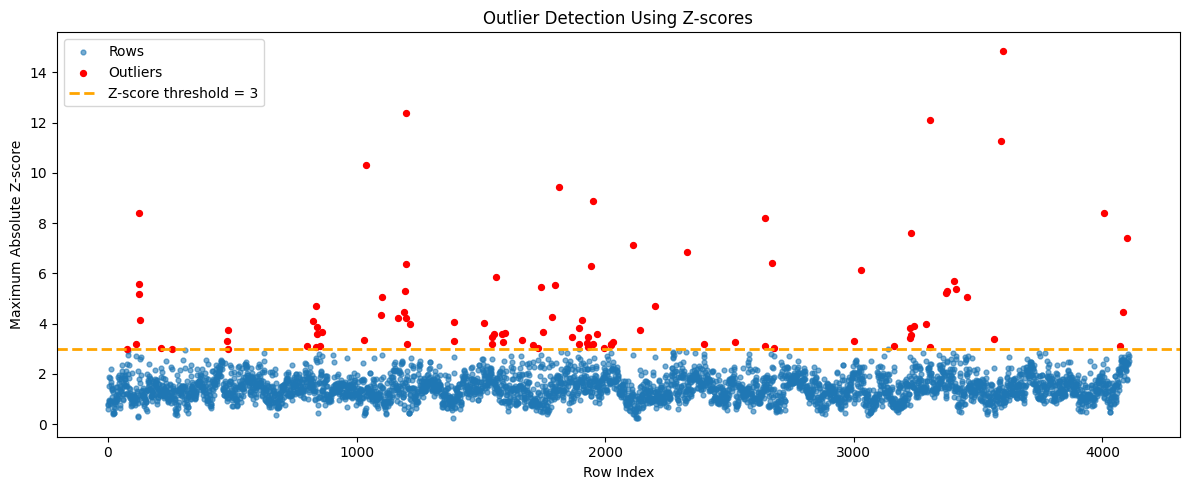

In [13]:
max_z = np.abs(z_scores).max(axis=1)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean.index, max_z, s=12, alpha=0.6, label="Rows")
plt.scatter(df_clean.index[outliers_mask], max_z[outliers_mask], color="red", s=18, label="Outliers")
plt.axhline(3, color="orange", linestyle="--", linewidth=2, label="Z-score threshold = 3")
plt.title("Outlier Detection Using Z-scores")
plt.xlabel("Row Index")
plt.ylabel("Maximum Absolute Z-score")
plt.legend()
plt.tight_layout()
plt.show()

### 🧹 Outlier Handling Strategy

Outliers were identified using Z-scores, with a threshold of (|Z| > 3). Rather than removing all outliers indiscriminately, a domain-aware approach was applied to distinguish between data errors, noise, and meaningful extreme weather events.

#### 1. Dropping Invalid Observations

Rows were **dropped** only when they violated known physical or logical constraints:

* ( T2M_MAX < T2M_MIN )
* ( T2M_RANGE \neq T2M_MAX - T2M_MIN )
* Relative humidity ((RH2M)) outside the range ([0, 100])
* Negative wind speed values

These represent data inconsistencies or measurement errors rather than true outliers.
In our case no such data was found. 

---

#### 2. Retaining Multi-variable Outliers

Rows where **two or more variables simultaneously exceeded the Z-score threshold** were **retained**. These accounted for approximately **1% of the dataset (6 rows)**.

These observations are likely to represent **real meteorological events**, such as:

* Storms (e.g., high wind speed and high precipitation)
* Temperature anomalies (e.g., unusually hot or cold days)

For example, **14 rows were identified as storm events and 4 rows were identified as heatwave days**, characterized by concurrent high values in `WS2M_MAX` and `PRECTOTCORR`. Such patterns are physically meaningful and should be preserved.
we have also seen all outliers might be rearly extreme values so the data outliers were all retained.

---

#### 3. Capping Single-variable Outliers

Rows where **only one variable exceeded the Z-score threshold** were treated as potential noise or measurement spikes. Instead of removing these rows, the extreme values were **capped** using percentile-based clipping (1st and 99th percentiles).

This approach:

* Reduces the impact of extreme values on analysis and modeling
* Preserves the overall structure and continuity of the dataset

In the data there were no single variable outliers

---

#### **Final Strategy Summary**

| Category                               | Action     | Rationale          |
| -------------------------------------- | ---------- | ------------------ |
| Physically inconsistent values         | **Drop**   | Data errors        |
| Multi-variable outliers (≥2 variables) | **Retain** | Likely real events |
| Single-variable outliers               | **Cap**    | Likely noise       |

---

This approach ensures that important extreme weather patterns are preserved while minimizing the influence of erroneous or noisy data points.


In [14]:
outlier_counts = pd.Series((z_scores > 3).sum(axis=0), index=cols_to_check)
total_rows_per_col = df_clean[cols_to_check].notna().sum(axis=0)

outlier_counts = pd.DataFrame({
    "Outlier_Count": outlier_counts,
    "Outlier_Percentage (%)": (outlier_counts / total_rows_per_col) * 100
})

print(outlier_counts)

             Outlier_Count  Outlier_Percentage (%)
T2M                      1                0.024343
T2M_MAX                  2                0.048685
T2M_MIN                  4                0.097371
PRECTOTCORR             81                1.971762
RH2M                     2                0.048685
WS2M                     8                0.194742
WS2M_MAX                 4                0.097371


### Detecting Invalid Observations

In [15]:
# Data quality checks
humidity_col = "RH2M" if "RH2M" in df_clean.columns else "Humidity"
wind_col = "WS2M" if "WS2M" in df_clean.columns else "Wind speed"

checks = pd.DataFrame(index=df_clean.index)

# 1) T2M_MAX < T2M_MIN
checks["T2M_MAX_lt_T2M_MIN"] = df_clean["T2M_MAX"] < df_clean["T2M_MIN"]

# 2) T2M_RANGE != T2M_MAX - T2M_MIN
expected_range = df_clean["T2M_MAX"] - df_clean["T2M_MIN"]
checks["T2M_RANGE_mismatch"] = ~np.isclose(df_clean["T2M_RANGE"], expected_range, equal_nan=True)

# 3) Humidity < 0 or > 100
checks["Humidity_out_of_bounds"] = (df_clean[humidity_col] < 0) | (df_clean[humidity_col] > 100)

# 4) Wind speed < 0
checks["Wind_speed_negative"] = df_clean[wind_col] < 0

# Combine and report
checks["any_issue"] = checks.any(axis=1)

print("Issue counts by rule:")
print(checks.drop(columns="any_issue").sum())

print(f"\nTotal rows with at least one issue: {checks['any_issue'].sum()}")

# Show problematic rows with relevant columns
problem_rows = df_clean.loc[
    checks["any_issue"],
    [c for c in ["Date", "T2M_MIN", "T2M_MAX", "T2M_RANGE", humidity_col, wind_col] if c in df_clean.columns]
].copy()

problem_rows["T2M_MAX_lt_T2M_MIN"] = checks.loc[checks["any_issue"], "T2M_MAX_lt_T2M_MIN"].values
problem_rows["T2M_RANGE_mismatch"] = checks.loc[checks["any_issue"], "T2M_RANGE_mismatch"].values
problem_rows["Humidity_out_of_bounds"] = checks.loc[checks["any_issue"], "Humidity_out_of_bounds"].values
problem_rows["Wind_speed_negative"] = checks.loc[checks["any_issue"], "Wind_speed_negative"].values

if not problem_rows.empty:
    print(problem_rows.head(10))

Issue counts by rule:
T2M_MAX_lt_T2M_MIN        0
T2M_RANGE_mismatch        0
Humidity_out_of_bounds    0
Wind_speed_negative       0
dtype: int64

Total rows with at least one issue: 0


In [16]:
df_temp = df_clean.copy()

In [17]:
df_temp["is_outlier"] = outliers_mask
df_temp["outlier_count"] = df_temp[cols_to_check].apply(lambda row: (row > 3).sum(), axis=1)

### Detect Multi-variable Outliers

In [18]:
T2M_idx = cols_to_check.index("T2M")
T2M_MAX_idx = cols_to_check.index("T2M_MAX")
T2M_MIN_idx = cols_to_check.index("T2M_MIN")
WS2M_MAX_idx = cols_to_check.index("WS2M_MAX")
PRECTOTCORR_idx = cols_to_check.index("PRECTOTCORR")
RH2M_idx = cols_to_check.index("RH2M")

df_temp["heatwave_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, T2M_idx] > 2) &
    (z_scores[:, T2M_MAX_idx] > 2) &
    (z_scores[:, T2M_MIN_idx] > 2)
)

df_temp["storm_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, WS2M_MAX_idx] > 2) &
    (z_scores[:, PRECTOTCORR_idx] > 2) &
    (df_temp["RH2M"] > 70)
)

In [19]:
heatwaves = df_temp["heatwave_flag"].sum()
storms = df_temp["storm_flag"].sum()
print("Number of heatwave days:", heatwaves)
print("Number of Storm days:", storms)

Number of heatwave days: 4
Number of Storm days: 14


In [20]:
outlier_mask = df_temp["is_outlier"]
outlier_df = df_temp.loc[outlier_mask]

# Run consistency checks only on outlier rows
temp_consistency = (
    (outlier_df["T2M_MIN"] <= outlier_df["T2M"]) &
    (outlier_df["T2M"] <= outlier_df["T2M_MAX"]) &
    (np.abs(outlier_df["T2M_RANGE"] - (outlier_df["T2M_MAX"] - outlier_df["T2M_MIN"])) < 1e-3)
)

wind_consistency = outlier_df["WS2M"] <= outlier_df["WS2M_MAX"]
humidity_consistency = (outlier_df["RH2M"] >= 0) & (outlier_df["RH2M"] <= 100)

p95_rain = outlier_df["PRECTOTCORR"].quantile(0.95)
storm_consistency = ~(
    (outlier_df["PRECTOTCORR"] > p95_rain) &
    (outlier_df["RH2M"] < 30)  # suspicious: heavy rain but very dry air
)

relationship_valid_outliers = (
    temp_consistency &
    wind_consistency &
    humidity_consistency &
    storm_consistency
)

# Map back to full index (non-outliers set to False)
relationship_valid = pd.Series(False, index=df_temp.index)
relationship_valid.loc[outlier_df.index] = relationship_valid_outliers

# Keep multi-variable logic within outliers only
multi_mask = outlier_mask & (df_temp["outlier_count"] >= 2)

valid_multi = multi_mask & relationship_valid
invalid_multi = multi_mask & ~relationship_valid

print("Outlier rows checked:", outlier_mask.sum())
print("Valid multi-variable outliers:", valid_multi.sum())
print("Invalid multi-variable outliers:", invalid_multi.sum())

Outlier rows checked: 97
Valid multi-variable outliers: 97
Invalid multi-variable outliers: 0


### Remove invalid multi-variable outliers

In [21]:
# Remove invalid multi-variable outliers using boolean masking
keep_mask_clean = ~invalid_multi.reindex(df_clean.index, fill_value=False)
keep_mask_temp = ~invalid_multi.reindex(df_temp.index, fill_value=False)

removed_clean = (~keep_mask_clean).sum()
removed_temp = (~keep_mask_temp).sum()

print(f"Invalid multi-variable outliers to remove from df_clean: {removed_clean}")
print(f"Invalid multi-variable outliers to remove from df_temp: {removed_temp}")

df_clean = df_clean[keep_mask_clean].copy()
df_temp = df_temp[keep_mask_temp].copy()

print("Masking applied to df_clean and df_temp.")

Invalid multi-variable outliers to remove from df_clean: 0
Invalid multi-variable outliers to remove from df_temp: 0
Masking applied to df_clean and df_temp.


In [22]:
print("Outlier rows checked:", df_temp["is_outlier"].sum())

Outlier rows checked: 97


## Handle remaining missing values

In [23]:
# check missing values
df_clean.isna().sum()

YEAR           0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

## Export the cleaned DataFrame

In [24]:
df_clean.head()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [25]:
os.makedirs("data", exist_ok=True)

country = "tanzania"
output_path = f"data/{country}_clean.csv"

print("Saving to:", os.path.abspath(output_path))

df_clean.to_csv(output_path, index=False)

print("Exists after save:", os.path.exists(output_path))
df_temp = pd.read_csv('data/tanzania_clean.csv')
df_temp.head()


Saving to: c:\Users\teMelkishi\Desktop\projects\tenx\projects\climate-challenge-week0\notebooks\data\tanzania_clean.csv
Exists after save: True


,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


# **Time Series Analysis**

In [26]:
df_clean["Month"].value_counts()

Month
1     372
3     372
5     341
7     341
8     341
10    341
12    341
2     339
4     330
6     330
9     330
11    330
Name: count, dtype: int64

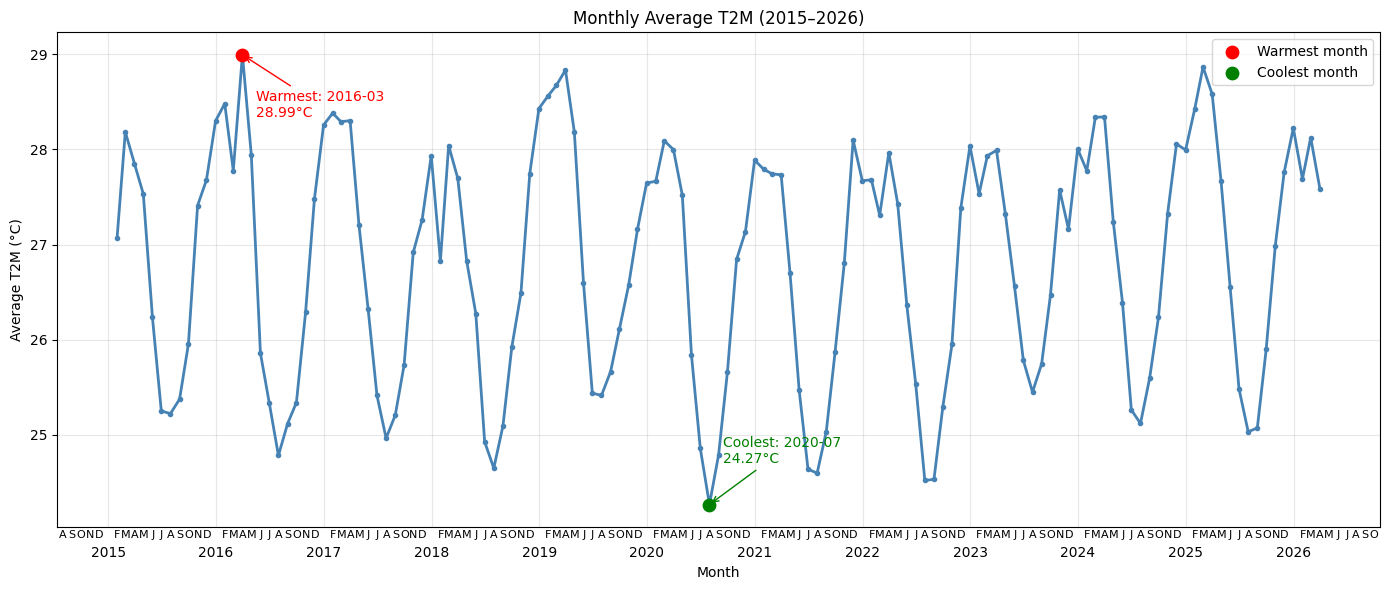

In [27]:
monthly_avg_t2m = df_clean.set_index("Date")["T2M"].resample("ME").mean()

warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_avg_t2m.index,
    monthly_avg_t2m.values,
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=3
)

plt.scatter([warmest_month], [monthly_avg_t2m[warmest_month]], color="red", s=80, zorder=5, label="Warmest month")
plt.scatter([coolest_month], [monthly_avg_t2m[coolest_month]], color="green", s=80, zorder=5, label="Coolest month")

plt.annotate(
    f"Warmest: {warmest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[warmest_month]:.2f}°C",
    xy=(warmest_month, monthly_avg_t2m[warmest_month]),
    xytext=(10, -45),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.annotate(
    f"Coolest: {coolest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[coolest_month]:.2f}°C",
    xy=(coolest_month, monthly_avg_t2m[coolest_month]),
    xytext=(10, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green"
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0]))

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

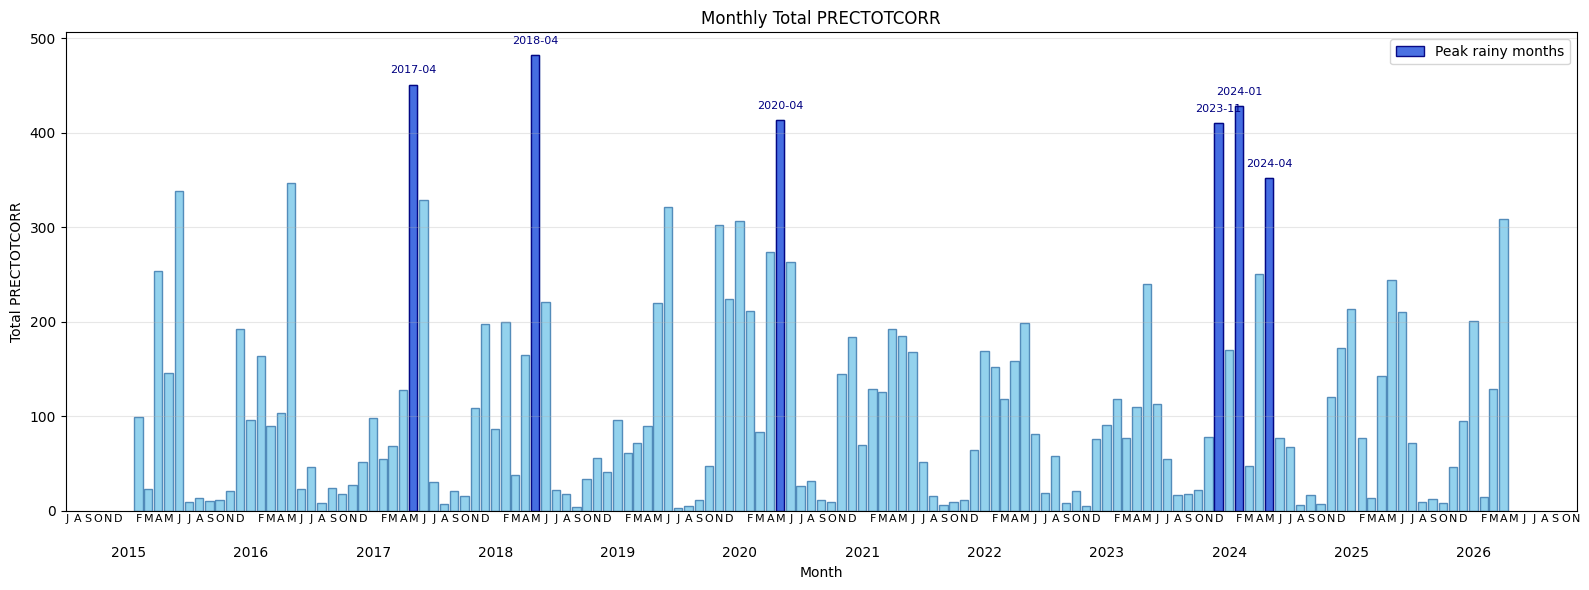

Peak rainy-season months (highest monthly totals):
Date
2017-04-30    451.12
2018-04-30    482.27
2020-04-30    413.10
2023-11-30    410.24
2024-01-31    428.57
2024-04-30    352.14
Name: PRECTOTCORR, dtype: float64


In [28]:
# Monthly total precipitation (PRECTOTCORR)
monthly_total_prectotcorr = df_clean.set_index("Date")["PRECTOTCORR"].resample("ME").sum()

# Pick peak rainy-season months (top 6 wettest months in the full time series)
peak_months = monthly_total_prectotcorr.nlargest(6).sort_index()

plt.figure(figsize=(16, 6))
plt.bar(
    monthly_total_prectotcorr.index,
    monthly_total_prectotcorr.values,
    width=25,
    color="skyblue",
    edgecolor="steelblue",
    alpha=0.9
)

# Highlight and annotate peak months
plt.bar(
    peak_months.index,
    peak_months.values,
    width=25,
    color="royalblue",
    edgecolor="navy",
    alpha=0.95,
    label="Peak rainy months"
)


for dt, val in peak_months.items():
    plt.annotate(
        dt.strftime("%Y-%m"),
        xy=(dt, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="navy"
    )

ax = plt.gca()

# Year label every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("\n%Y"))

# Month labels as first letter (J, F, M, ...)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(
    FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0])
)

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Total PRECTOTCORR")
plt.xlabel("Month")
plt.ylabel("Total PRECTOTCORR")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Peak rainy-season months (highest monthly totals):")
print(peak_months)

### **Precipitation (Monthly Total PRECTOTCORR)**
*   **Clear seasonal pattern**: The region exhibits a bimodal rainfall cycle. The primary "long rains" consistently peak in **March – May** (specifically **April**), while a secondary "short rains" period occurs between **October and January**. The driest months are consistently July through September, where rainfall is near zero.
*   **Key anomalies**:
    *   **Highest recorded rainfall**: **April 2018**, reaching a peak of approximately **485 mm**.
    *   Other significant peaks occurred in **April 2017** (~450 mm), **January 2024** (~430 mm), **April 2020** (~415 mm), and **November 2023** (~410 mm).
*   **Trend**: There is significant inter-annual variability. While the 2015–2016 period saw relatively moderate peaks, the years between 2017 and 2024 show more frequent and intense extreme rainfall events, with multiple months exceeding the 400 mm mark.

### **Temperature (Monthly Average T2M)**
*   **Clear seasonal cycle**: Temperatures follow a consistent annual trend with a range of approximately **24.3°C to 29.0°C**. Peaks generally occur in the first quarter of the year (**February – April**), while the coolest periods occur mid-year around **July**.
*   **Key anomalies**:
    *   **Warmest month**: **March 2016**, reaching a record high of **28.99°C**.
    *   **Coolest month**: **July 2020**, dropping to a record low of **24.27°C**.
*   **Trend**: While the overall temperature range has remained relatively stable, there is a visible increase in fluctuation intensity from 2023 onwards, with late 2024 and early 2025 showing peaks nearly as high as the 2016 record.

### **Relationship Between Precipitation and Temperature**
*   **Cooling effect of rain**: Heavy rainfall periods correlate with temperature declines. The warmest temperatures of the year consistently occur immediately before or during the onset of the "long rains" (March/April). As the rains persist and cloud cover increases, temperatures drop, reaching their annual minimum in July, just after the main rainy season ends.
*   **Notable co-occurrences**:
    *   **The 2020 Contrast**: The coolest month on record (**July 2020**) followed shortly after a major rainfall peak in **April 2020**, illustrating how a strong wet season can lead to a more pronounced seasonal cool-down.
    *   **2018 Peak**: The highest rainfall on record (**April 2018**) coincided with the start of the seasonal temperature descent.
*   **Implication**: Rainfall acts as a critical thermal regulator for the region. The highest heat stress occurs in the pre-monsoon months, and extreme rainfall events appear to drive more significant cooling in the subsequent months.

***

**Summary of Observations:**
The charts indicate that Tanzania is seeing an increase in the intensity of individual weather events, particularly with record-breaking rainfall peaks occurring more frequently since 2017. While **March 2016** remains the hottest month on record, recent years show a more volatile temperature profile. The inverse relationship between moisture and heat remains the dominant climatic driver, with the heaviest rains (April) reliably leading into the coolest part of the year (July).

# **Correlation & Relationship Analysis**

### Heatmap of correlations across all numeric columns

In [36]:
# which columns are numberic
df_clean.select_dtypes(include=[np.number]).columns.tolist()

['YEAR',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'PRECTOTCORR',
 'RH2M',
 'WS2M',
 'WS2M_MAX',
 'PS',
 'QV2M',
 'Month']

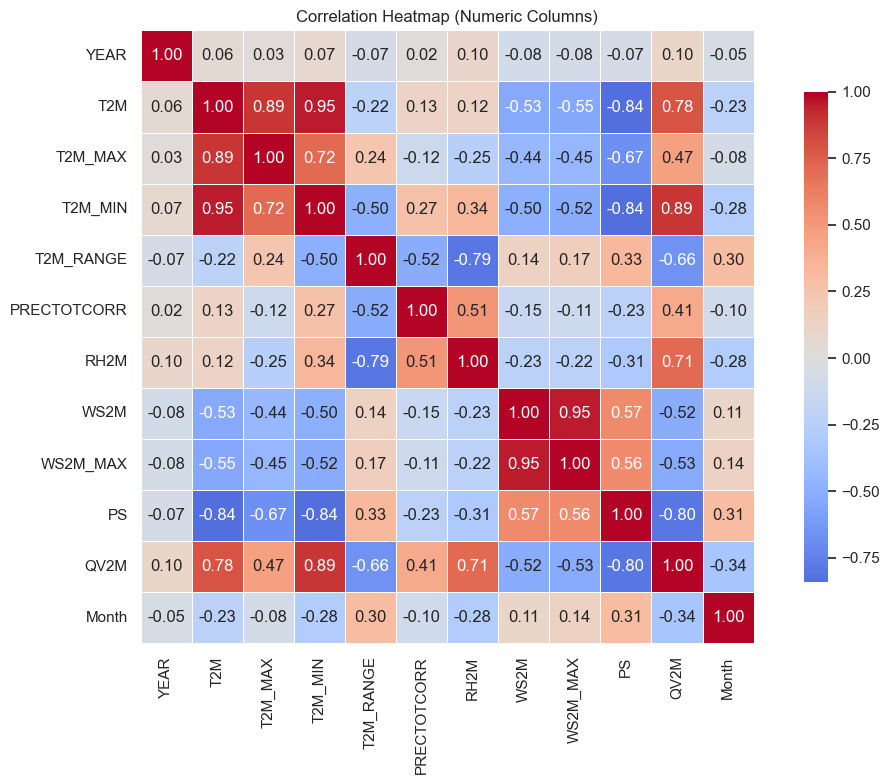

In [37]:
# Correlation heatmap across all numeric columns in df_clean
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

## Scatter plots

### T2M vs. RH2M and T2M_RANGE vs. WS2M

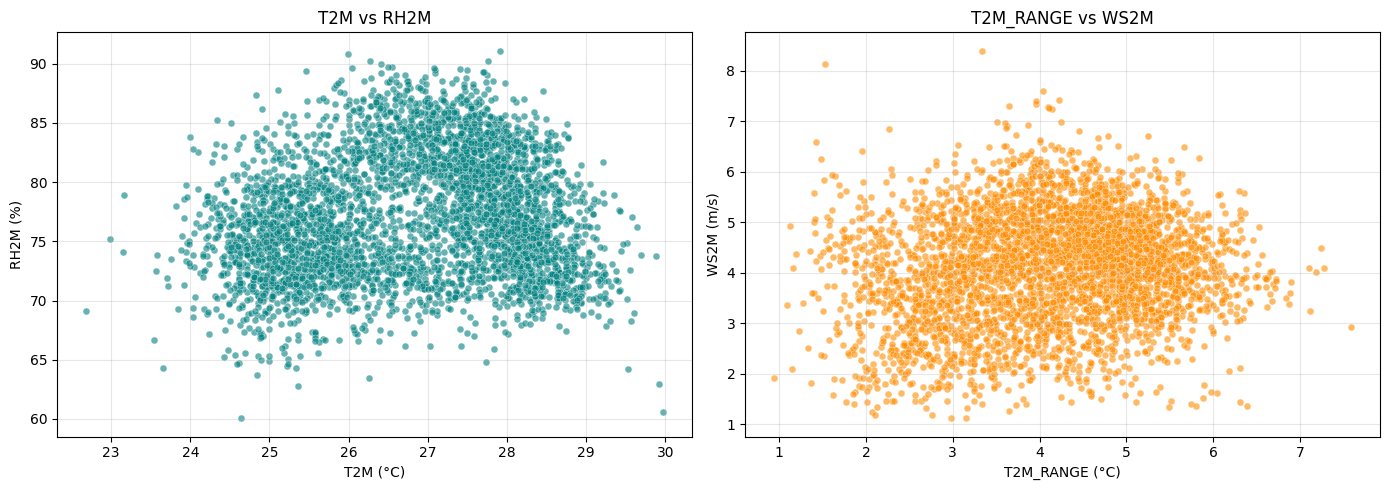

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clean, x="T2M", y="RH2M",
    alpha=0.6, s=25, ax=axes[0], color="teal"
)
axes[0].set_title("T2M vs RH2M")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].grid(alpha=0.3)

sns.scatterplot(
    data=df_clean, x="T2M_RANGE", y="WS2M",
    alpha=0.6, s=25, ax=axes[1], color="darkorange"
)
axes[1].set_title("T2M_RANGE vs WS2M")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Three Strongest Correlations

#### 1. Bimodal Relationship between T2M and RH2M (Left Plot)
*   **Identification:** The "T2M vs RH2M" plot shows a broad, dense cloud with two distinct "lobes" of concentration. One cluster is centered around **25°C with ~75% humidity**, while a second, slightly higher cluster is centered around **27–28°C with higher humidity (~80–85%)**.
*   **Interpretation:** Unlike arid regions where high heat leads to a "hook" and a drop in humidity, this region remains **consistently humid (mostly >70% RH)**. The higher temperature lobe (27–28°C) coincides with higher humidity, suggesting that the warmest periods are likely associated with peak moisture-bearing seasons (like the "long rains" identified in the previous bar charts).

#### 2. Weak Positive Correlation: T2M_RANGE vs WS2M (Right Plot)
*   **Identification:** There is a **very weak, diffuse positive correlation** between the diurnal temperature range and wind speed. The bulk of the data is concentrated between a temperature range of **3°C to 6°C** and wind speeds of **2 to 5 m/s**.
*   **Interpretation:** While the correlation is low, there is a slight tendency for windier days to experience a slightly larger diurnal temperature variation. The small overall temperature range (rarely exceeding 7°C) is typical of a humid, tropical, or maritime environment where moisture acts as a thermal buffer, preventing extreme day-night temperature swings.

***

### Key Takeaway
The most striking feature of these plots is the **absence of a dry regime**. The atmosphere remains saturated (Relative Humidity consistently between 60% and 90%), even as temperatures rise to their maximum of ~30°C. This confirms the previous observation that the region (Tanzania) is dominated by high moisture availability, where **increasing temperatures are often coupled with increasing humidity** rather than drying out.

# **Distribution Analysis**

In [38]:
df_clean.head()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


### **Histogram of PRECTOTCORR**

#### Check if the histogram of PRECTOTCORR

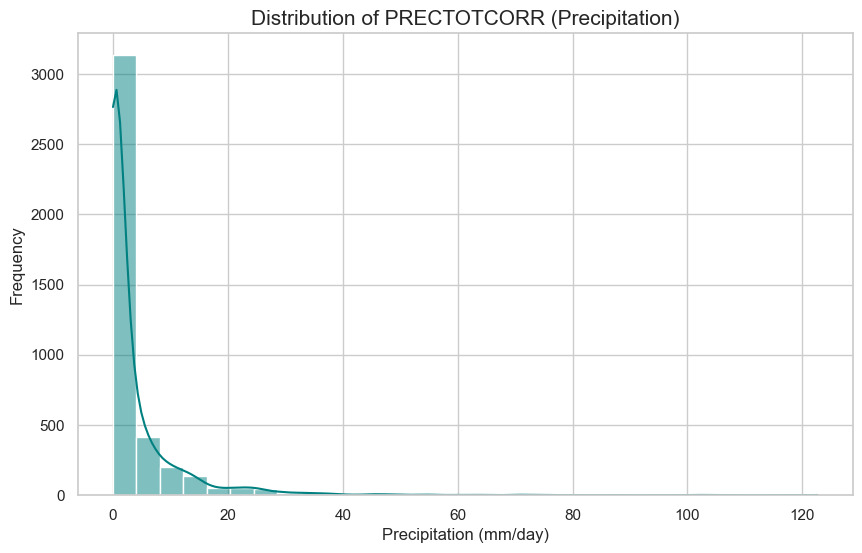

In [39]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], kde=True, color='teal', bins=30)

plt.title('Distribution of PRECTOTCORR (Precipitation)', fontsize=15)
plt.xlabel('Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Because the distribution of PRECTOTCORR is heavily skewed we apply log scale to the X-axis to better visualize the distribution.

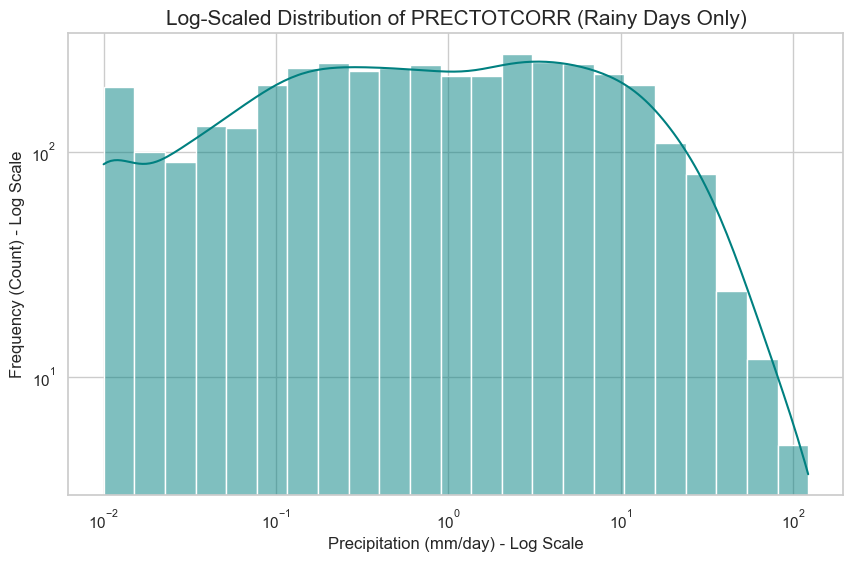

In [40]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6)) 

# Filtering for values > 0 is necessary for log scales because log(0) is undefined
rainy_days = df[df['PRECTOTCORR'] > 0]['PRECTOTCORR']

# log_scale=True automatically calculates log-spaced bins for the X-axis
sns.histplot(rainy_days, kde=True, color='teal', log_scale=True)

# Also applying log scale to the Y-axis (Frequency) to see rare extreme events better
plt.yscale('log')

plt.title('Log-Scaled Distribution of PRECTOTCORR (Rainy Days Only)', fontsize=15)
plt.xlabel('Precipitation (mm/day) - Log Scale', fontsize=12)
plt.ylabel('Frequency (Count) - Log Scale', fontsize=12)

plt.show()

### **Bubble chart**

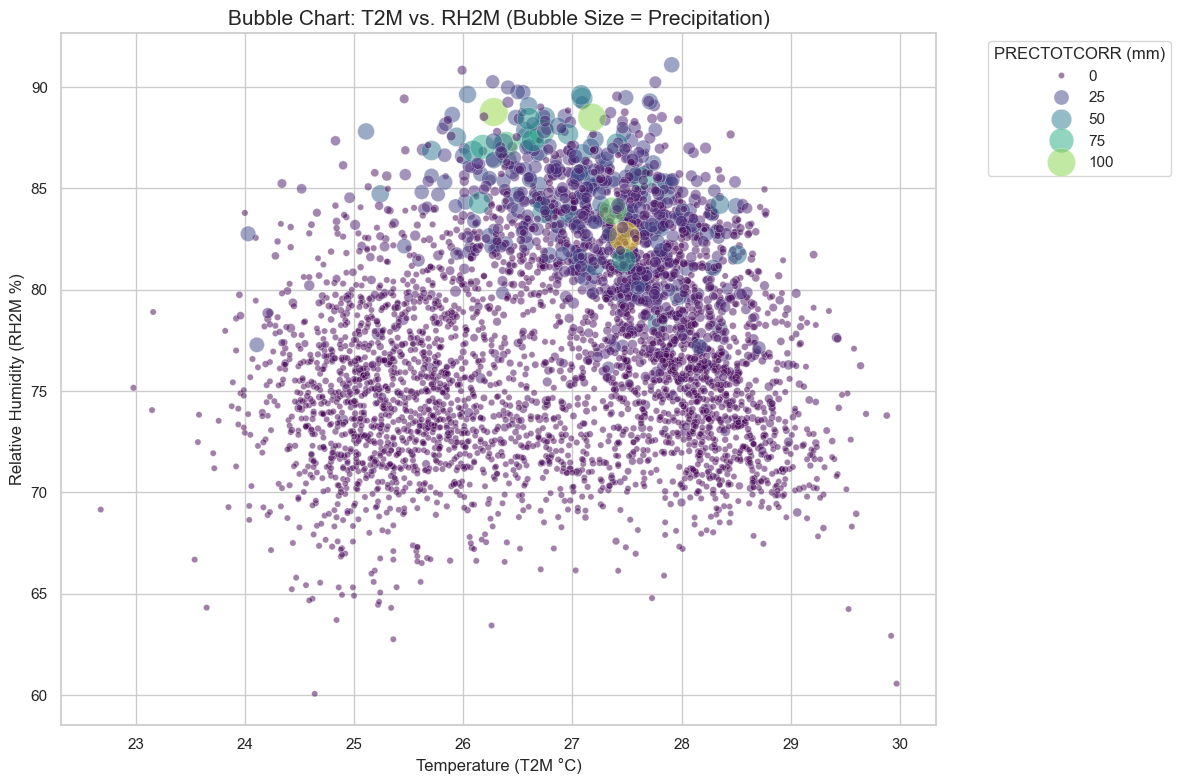

In [41]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# Create the bubble chart
# s=df['PRECTOTCORR'] * 20: Scale factor to make bubbles visible
# alpha=0.5: Transparency to see overlapping bubbles
# hue='PRECTOTCORR': Colors bubbles by precipitation intensity for better clarity
bubble_plot = sns.scatterplot(
    data=df, 
    x='T2M', 
    y='RH2M', 
    size='PRECTOTCORR', 
    hue='PRECTOTCORR',
    sizes=(20, 500),      
    alpha=0.5,           
    palette='viridis'     
)

# Customizing the chart
plt.title('Bubble Chart: T2M vs. RH2M (Bubble Size = Precipitation)', fontsize=15)
plt.xlabel('Temperature (T2M °C)', fontsize=12)
plt.ylabel('Relative Humidity (RH2M %)', fontsize=12)

# Move the legend outside to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='PRECTOTCORR (mm)')

plt.tight_layout()
plt.show()

### Interpretation of Bubble Chart: T2M vs. RH2M (Precipitation)

This bubble chart adds a third dimension, **Precipitation (PRECTOTCORR)**, to the relationship between temperature and relative humidity for the study area. Here is an analysis of the key patterns observed:

#### 1. The "Rainy Section"
*   **Observation:** The largest bubbles (representing high precipitation, **75mm to 100mm+**) are exclusively clustered at the very top of the graph.
*   **Interpretation:** Significant rainfall in this region is strictly tied to extreme atmospheric saturation. Heavy rain only occurs when **Relative Humidity exceeds 82%**. Below the 75% RH threshold, precipitation is almost entirely absent (indicated by the dense field of tiny purple dots), regardless of the temperature.

#### 2. Narrow Temperature Window for Peak Precipitation
*   **Observation:** The heaviest rainfall events (the large light-green and yellow bubbles) are concentrated within a very narrow temperature window, specifically between **26°C and 28.5°C**.
*   **Interpretation:** Unlike the previous general assumption of a wide window, this specific data shows that peak precipitation is highly sensitive to temperature. If the air is too "cool" (below 25°C) or too "warm" (approaching 30°C), the massive moisture dumping required for 100mm+ events does not occur.

#### 3. The "Humid-Dry" Regime
*   **Observation:** A massive cluster of purple dots (zero or near-zero rain) exists between **65% and 80% RH**.
*   **Interpretation:** In this specific climate (likely a coastal tropical region like Tanzania), "dry" is a relative term. Even when the air is quite humid by global standards (70% RH), it is still too "dry" to produce significant rain in this environment. This demonstrates that a very high threshold of saturation must be met before precipitation is triggered.

#### 4. High-Temperature Suppression
*   **Observation:** As temperatures climb toward **29°C and 30°C**, the Relative Humidity consistently drops toward the 60–70% range, and the bubbles vanish.
*   **Interpretation:** Even a slight increase in temperature (from 28°C to 30°C) appears to drive down relative humidity enough to move the atmosphere out of the "precipitation zone." The hottest days on this chart are consistently the ones with the lowest rainfall.

#### 5. Local Peak Anomaly
*   **Observation:** There is a distinct "highest" rainfall event (the yellowest bubble) located at approximately **27.5°C and 83% RH**.
*   **Interpretation:** While most peak rain happens at 85–90% RH, this specific event suggests that at the ideal temperature of ~27.5°C, the atmosphere can trigger massive precipitation even with slightly less saturation than the other peak events.

### Summary
The chart demonstrates a **precise climatic threshold**: heavy precipitation in this region is not just about being "hot and wet," but specifically about hitting a **"Triple Point"** of roughly **27°C, >85% humidity, and high precipitation**. Any deviation—either a 2-degree rise in temperature or a 10% drop in humidity—results in a complete cessation of significant rainfall.